# Fase D — Visualizaciones
### Proyecto 1 — Bodega de siniestralidad vial (2016-2024)

Este notebook toma las 6 consultas SQL analíticas de la **Fase C** (`fase_c_sql.ipynb`) y produce
**8 visualizaciones** a partir de sus resultados, cubriendo los cuatro tipos exigidos:

| # | Visualización | Tipo exigido |
|---|---|---|
| 1 | Evolución semanal de siniestros (2016-2024) | Serie de tiempo |
| 2 | Distribución de la cantidad de siniestros por semana | Distribución univariada |
| 3 | Siniestros por día de la semana | Comparación categórica |
| 4 | Siniestros por mes | Comparación categórica |
| 5 | Motocicletas vs. automóviles por semana | Relación bivariada |
| 6 | Categoría de vehículo dominante por semana | Comparación categórica |
| 7 | Siniestros por día de la semana y gravedad | Mapa de calor |
| 8 | Top 10 combinaciones tipo de accidente–gravedad | Comparación categórica |

Cada visualización reutiliza el SQL de la Fase C (consultas `q1` a `q6`) contra la bodega dimensional
(`fact_siniestro`, `dim_tiempo`, `dim_gravedad`, `dim_tipo_accidente`, `dim_tipo_vehiculo`,
`dim_ubicacion`, `dim_medio_reporte`, `bridge_siniestro_vehiculo`).

## Conexión a la bodega de datos

In [1]:
%pip install matplotlib seaborn --quiet

%matplotlib inline

import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.exc import SQLAlchemyError

load_dotenv()
DATABASE_URL = os.getenv("DATABASE_URL")

if not DATABASE_URL:
    raise ValueError("No se encontró DATABASE_URL en el archivo .env.")

try:
    engine = create_engine(DATABASE_URL)
    with engine.connect() as conexion:
        conexion.execute(text("SELECT 1"))
    print("Conexión exitosa a PostgreSQL.")
except SQLAlchemyError as error:
    raise SystemExit(f"No se pudo conectar a la bodega de datos: {error}")

# Estilo visual consistente
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

COLOR_PRINCIPAL = "#2E86AB"
COLOR_SECUNDARIO = "#A23B72"

# Carpeta para guardar las figuras (para reutilizar en el informe)
FIG_DIR = Path("figuras")
FIG_DIR.mkdir(exist_ok=True)
print(f"Carpeta de figuras lista: {FIG_DIR.resolve()}")


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Conexión exitosa a PostgreSQL.
Carpeta de figuras lista: C:\Users\usuario\Downloads\Laboratorios\Ciencias-de-datos\entrega\figuras


## 1. Evolución semanal de siniestros (2016-2024)
**Tipo: serie de tiempo**

Reutiliza la consulta `q1` de la Fase C (semanas con mayor cantidad de siniestros, con `RANK()`),
pero aquí se ordena cronológicamente en vez de por ranking para observar la evolución en el tiempo.

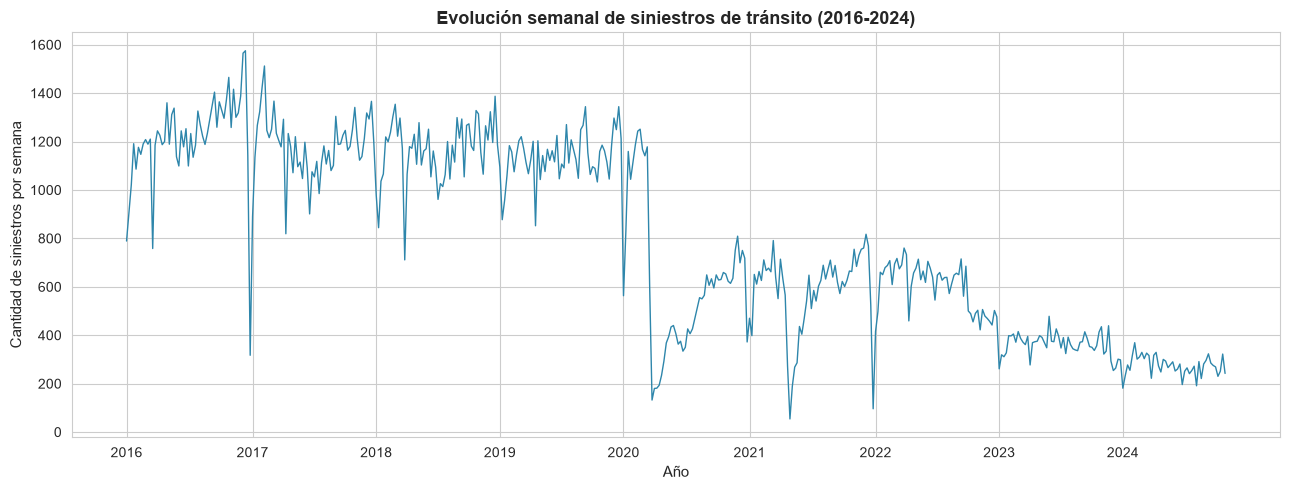

In [11]:
q1 = """
SELECT
    t.anio,
    t.semana_anio,
    SUM(f.cantidad_siniestros) AS cantidad_siniestros,
    RANK() OVER (
        ORDER BY SUM(f.cantidad_siniestros) DESC
    ) AS ranking
FROM fact_siniestro AS f
JOIN dim_tiempo AS t
    ON f.id_tiempo = t.id_tiempo
GROUP BY
    t.anio,
    t.semana_anio
ORDER BY
    ranking;
"""

r1 = pd.read_sql(q1, engine)

serie_semanal = r1.sort_values(
    ["anio", "semana_anio"]
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(
    range(len(serie_semanal)),
    serie_semanal["cantidad_siniestros"],
    color=COLOR_PRINCIPAL,
    linewidth=1
)

# Marcar el inicio de cada año en el eje x
inicios_anio = serie_semanal.reset_index().groupby("anio")["index"].min()

ax.set_xticks(inicios_anio.values)
ax.set_xticklabels(inicios_anio.index)

ax.set_title("Evolución semanal de siniestros de tránsito (2016-2024)")
ax.set_xlabel("Año")
ax.set_ylabel("Cantidad de siniestros por semana")

plt.tight_layout()

# Guardar la gráfica
plt.savefig(
    "graficas/grafica_1_siniestros_semanales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Insight:** La serie muestra una caída abrupta hacia las semanas 13-18 de 2020, coincidiendo con las restricciones de movilidad por COVID-19, con mínimos de 54 siniestros semanales en 2021. Fuera de ese quiebre, el nivel se mantiene estable, con picos recurrentes hacia el cierre de cada año (últimas semanas de 2016 y primeras de 2017). Esto sugiere que la siniestralidad responde a factores externos extraordinarios y a la estacionalidad de fin de año.

## 2. Distribución de la cantidad de siniestros por semana
**Tipo: distribución univariada**

Usa la misma columna `cantidad_siniestros` de la consulta `q1`, ahora vista como distribución en
lugar de serie temporal.

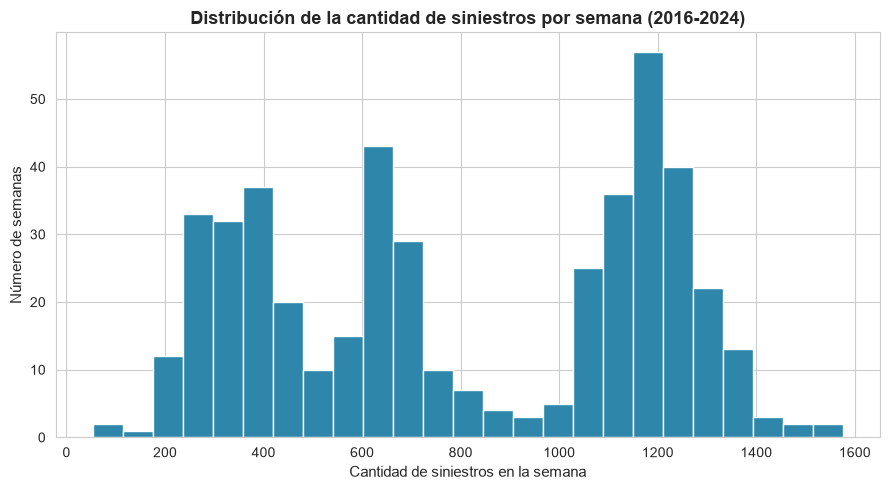

count     463.000000
mean      801.291577
std       386.097944
min        54.000000
25%       415.000000
50%       715.000000
75%      1178.500000
max      1575.000000
Name: cantidad_siniestros, dtype: float64


In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    serie_semanal["cantidad_siniestros"],
    bins=25,
    color=COLOR_PRINCIPAL,
    edgecolor="white"
)

ax.set_title("Distribución de la cantidad de siniestros por semana (2016-2024)")

ax.set_xlabel("Cantidad de siniestros en la semana")

ax.set_ylabel("Número de semanas")

plt.tight_layout()

# Guardar la gráfica
plt.savefig(
    "graficas/grafica_2_distribucion_siniestros.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(serie_semanal["cantidad_siniestros"].describe())

**Insight:** La distribución se concentra en un rango central de semanas "normales", con colas hacia ambos lados: mínimos de 54 siniestros en 2020-2021 por la pandemia y máximos de 1.575 en la semana 51 de 2016. Esta dispersión confirma que, aunque el comportamiento semanal es en general estable, existen eventos extraordinarios que conviene tratar como atípicos en cualquier análisis de tendencia.

## 3. Siniestros por día de la semana
**Tipo: comparación categórica**

Reutiliza la consulta `q4` de la Fase C tal cual.

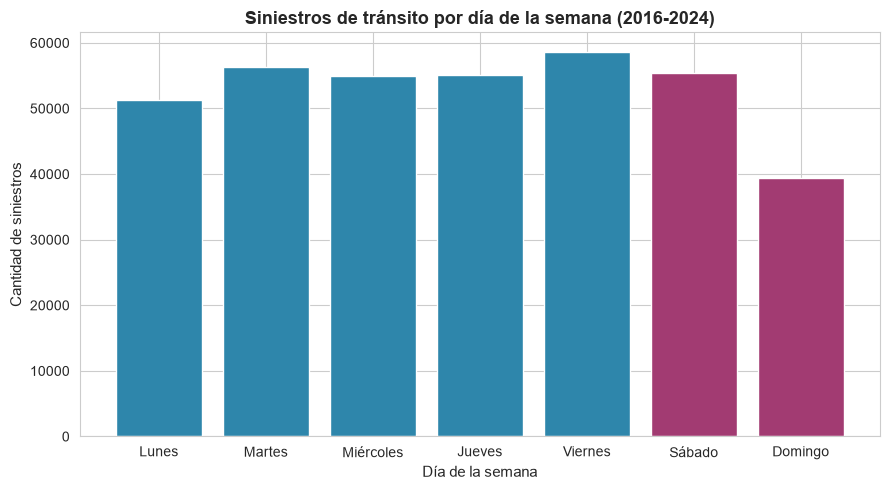

In [13]:
q4 = """
SELECT
    t.dia_semana_num,
    t.nombre_dia_semana,
    SUM(f.cantidad_siniestros) AS cantidad_siniestros
FROM fact_siniestro AS f
JOIN dim_tiempo AS t
    ON f.id_tiempo = t.id_tiempo
GROUP BY
    t.dia_semana_num,
    t.nombre_dia_semana
ORDER BY
    cantidad_siniestros DESC;
"""
r4 = pd.read_sql(q4, engine)

dias_es = {
    "Monday": "Lunes", "Tuesday": "Martes", "Wednesday": "Miércoles",
    "Thursday": "Jueves", "Friday": "Viernes", "Saturday": "Sábado", "Sunday": "Domingo"
}
r4_plot = r4.sort_values("dia_semana_num").copy()
r4_plot["dia"] = r4_plot["nombre_dia_semana"].map(dias_es)

colores = [COLOR_SECUNDARIO if d in ("Sábado", "Domingo") else COLOR_PRINCIPAL for d in r4_plot["dia"]]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(r4_plot["dia"], r4_plot["cantidad_siniestros"], color=colores)
ax.set_title("Siniestros de tránsito por día de la semana (2016-2024)")
ax.set_xlabel("Día de la semana")
ax.set_ylabel("Cantidad de siniestros")
plt.tight_layout()

# Guardar la gráfica
plt.savefig(
    "graficas/grafica_3_dia_semana.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Insight:** El viernes concentra la mayor cantidad de siniestros del período (58.673), seguido de martes (56.283) y sábado (55.358), mientras que el domingo es el día con menor siniestralidad (39.367 siniestros, ~33% menos que el viernes). El patrón sugiere que la mayor exposición al riesgo ocurre en días laborales de alto tráfico y en la salida del fin de semana (viernes), más que en el fin de semana propiamente dicho. Esto tiene implicaciones directas para la asignación de agentes de tránsito, que deberían reforzarse los viernes.

## 4. Siniestros por mes
**Tipo: comparación categórica**

Reutiliza la consulta `q2` de la Fase C, reordenada por mes calendario para facilitar la lectura.

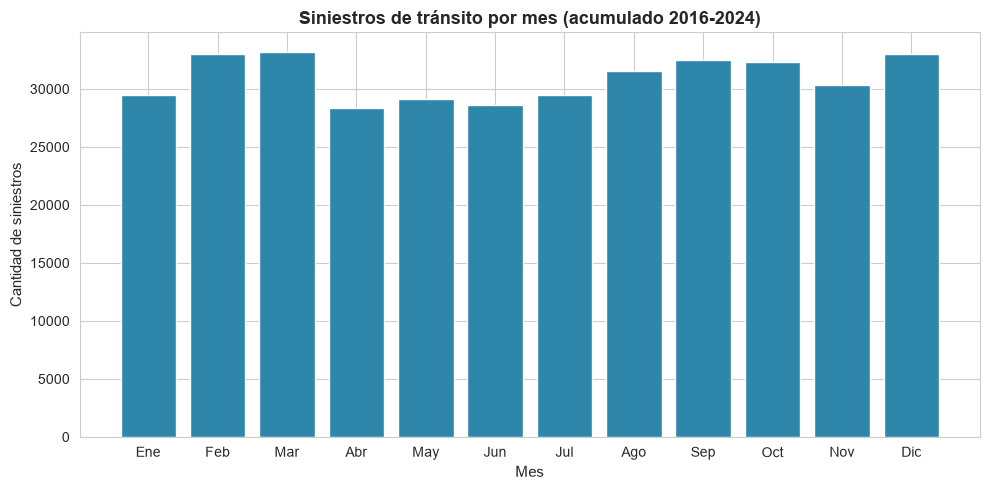

In [14]:
q2 = """
SELECT
    t.mes,
    t.nombre_mes,
    SUM(f.cantidad_siniestros) AS cantidad_siniestros
FROM fact_siniestro AS f
JOIN dim_tiempo AS t
    ON f.id_tiempo = t.id_tiempo
GROUP BY
    t.mes,
    t.nombre_mes
ORDER BY
    cantidad_siniestros ASC;
"""
r2 = pd.read_sql(q2, engine)

meses_es = {1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr", 5: "May", 6: "Jun",
            7: "Jul", 8: "Ago", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"}
r2_plot = r2.sort_values("mes").copy()
r2_plot["mes_es"] = r2_plot["mes"].map(meses_es)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(r2_plot["mes_es"], r2_plot["cantidad_siniestros"], color=COLOR_PRINCIPAL)
ax.set_title("Siniestros de tránsito por mes (acumulado 2016-2024)")
ax.set_xlabel("Mes")
ax.set_ylabel("Cantidad de siniestros")
plt.tight_layout()

# Guardar la gráfica
plt.savefig(
    "graficas/grafica_4_mes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Insight:** Marzo es el mes con más siniestros acumulados (33.221), seguido de diciembre (33.044) y febrero (32.983), mientras que abril es el mes con menos (28.366). La diferencia entre el mes más alto y el más bajo es del 17%. Esto sugiere que la siniestralidad no se concentra únicamente en la temporada de vacaciones de fin de año, sino que también es alta en meses de retorno a la actividad laboral y escolar.

## 5. Motocicletas vs. automóviles por semana
**Tipo: relación bivariada**

Reutiliza la consulta `q3` de la Fase C (semanas donde los siniestros con motocicleta superan a los
de automóvil), graficando sus dos columnas numéricas una contra la otra.

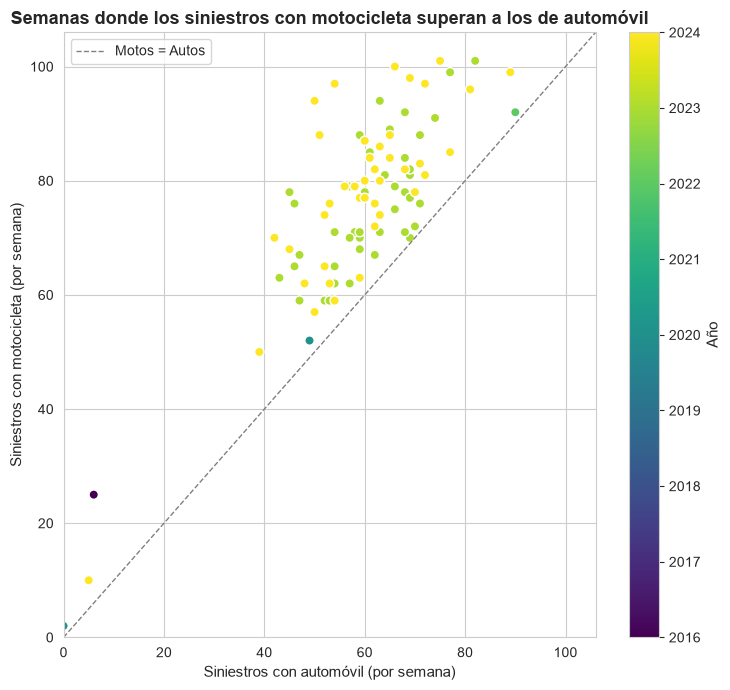

In [15]:
q3 = """
SELECT
    t.anio,
    t.semana_anio,
    COUNT(DISTINCT CASE
        WHEN v.categoria_vehiculo = 'MOTOCICLETA'
        THEN f.id_siniestro
    END) AS siniestros_motocicleta,
    COUNT(DISTINCT CASE
        WHEN v.tipo_vehiculo_estandarizado LIKE '%AUTOMOVIL%'
        THEN f.id_siniestro
    END) AS siniestros_automovil
FROM fact_siniestro AS f
JOIN dim_tiempo AS t
    ON f.id_tiempo = t.id_tiempo
JOIN bridge_siniestro_vehiculo AS b
    ON f.id_siniestro = b.id_siniestro
JOIN dim_tipo_vehiculo AS v
    ON b.id_tipo_vehiculo = v.id_tipo_vehiculo
GROUP BY
    t.anio,
    t.semana_anio
HAVING
    COUNT(DISTINCT CASE
        WHEN v.categoria_vehiculo = 'MOTOCICLETA'
        THEN f.id_siniestro
    END)
    >
    COUNT(DISTINCT CASE
        WHEN v.tipo_vehiculo_estandarizado LIKE '%AUTOMOVIL%'
        THEN f.id_siniestro
    END)
ORDER BY
    t.anio,
    t.semana_anio;
"""
from sqlalchemy import text

r3 = pd.read_sql(text(q3), engine)

fig, ax = plt.subplots(figsize=(7.5, 7))
dispersion = ax.scatter(
    r3["siniestros_automovil"], r3["siniestros_motocicleta"],
    c=r3["anio"], cmap="viridis", s=45, edgecolor="white"
)
limite = max(r3["siniestros_automovil"].max(), r3["siniestros_motocicleta"].max()) + 5
ax.plot([0, limite], [0, limite], linestyle="--", color="gray", linewidth=1, label="Motos = Autos")
ax.set_xlim(0, limite)
ax.set_ylim(0, limite)
ax.set_title("Semanas donde los siniestros con motocicleta superan a los de automóvil")
ax.set_xlabel("Siniestros con automóvil (por semana)")
ax.set_ylabel("Siniestros con motocicleta (por semana)")
ax.legend()
fig.colorbar(dispersion, label="Año")
plt.tight_layout()

# Guardar la gráfica
plt.savefig(
    "graficas/grafica_5_motos_vs_autos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Insight:** Todos los puntos quedan por encima de la línea de referencia (motos = autos), como corresponde al filtro HAVING de la consulta, pero lo relevante es su distribución temporal. El color muestra que estas semanas se concentran en 2022-2024, con hasta 101 siniestros con motocicleta en la semana 43 de 2024, frente a magnitudes mucho menores en 2016 o 2020. Esto sugiere que la sobreexposición de las motocicletas se intensifica hacia el final del período y debería ser prioridad en políticas de seguridad vial.

## 6. Categoría de vehículo dominante por semana
**Tipo: comparación categórica**

Parte de la consulta `q5` de la Fase C (categoría de vehículo más frecuente por semana, con
`ROW_NUMBER()`), y en pandas cuenta en cuántas semanas cada categoría ocupó el primer lugar.

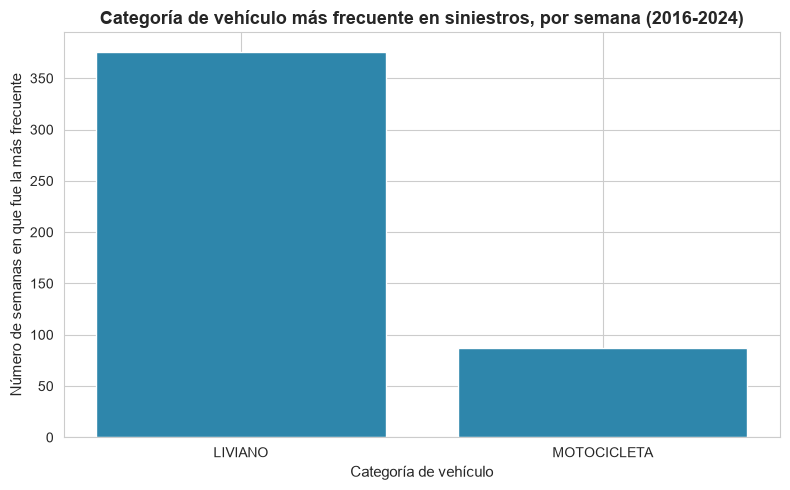

In [16]:
q5 = """
WITH frecuencia_vehiculos AS (
    SELECT
        t.anio,
        t.semana_anio,
        v.categoria_vehiculo,
        COUNT(DISTINCT f.id_siniestro) AS cantidad_siniestros
    FROM fact_siniestro AS f
    JOIN dim_tiempo AS t
        ON f.id_tiempo = t.id_tiempo
    JOIN bridge_siniestro_vehiculo AS b
        ON f.id_siniestro = b.id_siniestro
    JOIN dim_tipo_vehiculo AS v
        ON b.id_tipo_vehiculo = v.id_tipo_vehiculo
    GROUP BY
        t.anio,
        t.semana_anio,
        v.categoria_vehiculo
),
ranking_vehiculos AS (
    SELECT
        anio,
        semana_anio,
        categoria_vehiculo,
        cantidad_siniestros,
        ROW_NUMBER() OVER (
            PARTITION BY anio, semana_anio
            ORDER BY cantidad_siniestros DESC
        ) AS posicion
    FROM frecuencia_vehiculos
)
SELECT
    anio,
    semana_anio,
    categoria_vehiculo,
    cantidad_siniestros
FROM ranking_vehiculos
WHERE posicion = 1
ORDER BY
    anio,
    semana_anio;
"""
r5 = pd.read_sql(q5, engine)

conteo_dominancia = (
    r5.groupby("categoria_vehiculo")["semana_anio"]
    .count()
    .sort_values(ascending=False)
    .rename("semanas_como_dominante")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(conteo_dominancia["categoria_vehiculo"], conteo_dominancia["semanas_como_dominante"],
       color=COLOR_PRINCIPAL)
ax.set_title("Categoría de vehículo más frecuente en siniestros, por semana (2016-2024)")
ax.set_xlabel("Categoría de vehículo")
ax.set_ylabel("Número de semanas en que fue la más frecuente")
plt.tight_layout()

# Guardar la gráfica
plt.savefig(
    "graficas/grafica_6_categoria_dominante.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Insight:** En las primeras semanas del período (2016) la categoría LIVIANO (automóviles, taxis, camperos) es la más frecuente en los siniestros semanales, mientras que en 2024 ese lugar lo ocupa de forma consistente MOTOCICLETA. Este cambio es coherente con el crecimiento del parque de motocicletas en el país. Refuerza el hallazgo de la visualización anterior: el peso de las motos en la siniestralidad crece sostenidamente.

## 7. Siniestros por día de la semana y gravedad
**Tipo: mapa de calor (comparación categórica multidimensional)**

Reutiliza la consulta `q6` de la Fase C (día de la semana, tipo de accidente y gravedad) y la
convierte en una tabla dinámica día × gravedad.

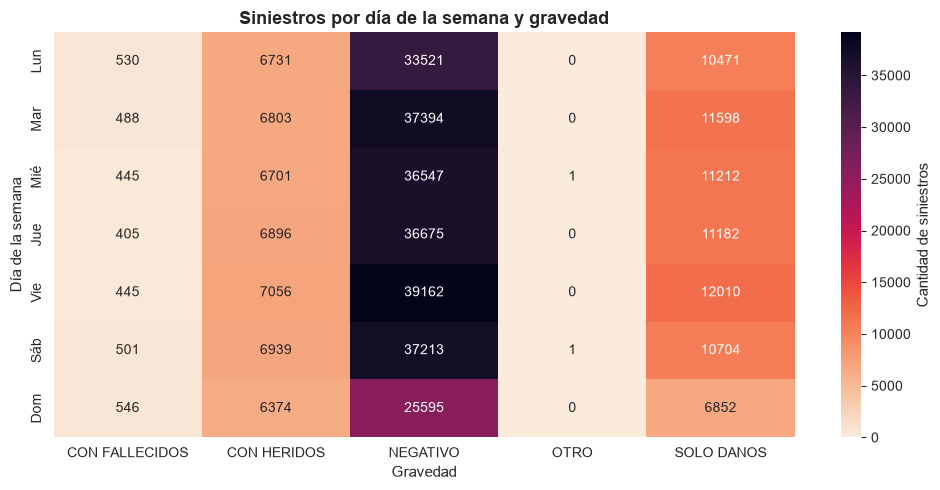

In [17]:
q6 = """
SELECT
    t.nombre_dia_semana,
    a.tipo_accidente_estandarizado,
    g.gravedad_estandarizada,
    SUM(f.cantidad_siniestros) AS cantidad_siniestros
FROM fact_siniestro AS f
JOIN dim_tiempo AS t
    ON f.id_tiempo = t.id_tiempo
JOIN dim_tipo_accidente AS a
    ON f.id_tipo_accidente = a.id_tipo_accidente
JOIN dim_gravedad AS g
    ON f.id_gravedad = g.id_gravedad
GROUP BY
    t.dia_semana_num,
    t.nombre_dia_semana,
    a.tipo_accidente_estandarizado,
    g.gravedad_estandarizada
ORDER BY
    t.dia_semana_num,
    cantidad_siniestros DESC;
"""
r6 = pd.read_sql(q6, engine)

orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dias_es = {"Monday": "Lun", "Tuesday": "Mar", "Wednesday": "Mié", "Thursday": "Jue",
           "Friday": "Vie", "Saturday": "Sáb", "Sunday": "Dom"}

pivote_gravedad = (
    r6.groupby(["nombre_dia_semana", "gravedad_estandarizada"])["cantidad_siniestros"]
    .sum()
    .unstack(fill_value=0)
    .reindex(orden_dias)
)
pivote_gravedad.index = [dias_es[d] for d in pivote_gravedad.index]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivote_gravedad, annot=True, fmt=".0f", cmap="rocket_r", ax=ax,
            cbar_kws={"label": "Cantidad de siniestros"})
ax.set_title("Siniestros por día de la semana y gravedad")
ax.set_xlabel("Gravedad")
ax.set_ylabel("Día de la semana")
plt.tight_layout()

# Guardar la gráfica
plt.savefig(
    "graficas/grafica_7_heatmap_dia_gravedad.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Insight:** La categoría NEGATIVO (sin confirmación de daños ni lesiones) domina con claridad todos los días de la semana, con valores muy superiores a los de SOLO DAÑOS, CON HERIDOS y CON FALLECIDOS. Los siniestros con víctimas (heridos o fallecidos), aunque menos frecuentes en términos absolutos, son el foco más relevante para política pública de seguridad vial. El heatmap permite identificar rápidamente qué combinaciones día-gravedad concentran la mayor siniestralidad.

## 8. Top 10 combinaciones de tipo de accidente y gravedad
**Tipo: comparación categórica**

También parte de `q6`, agregando en pandas por combinación de tipo de accidente y gravedad, sin
distinguir por día.

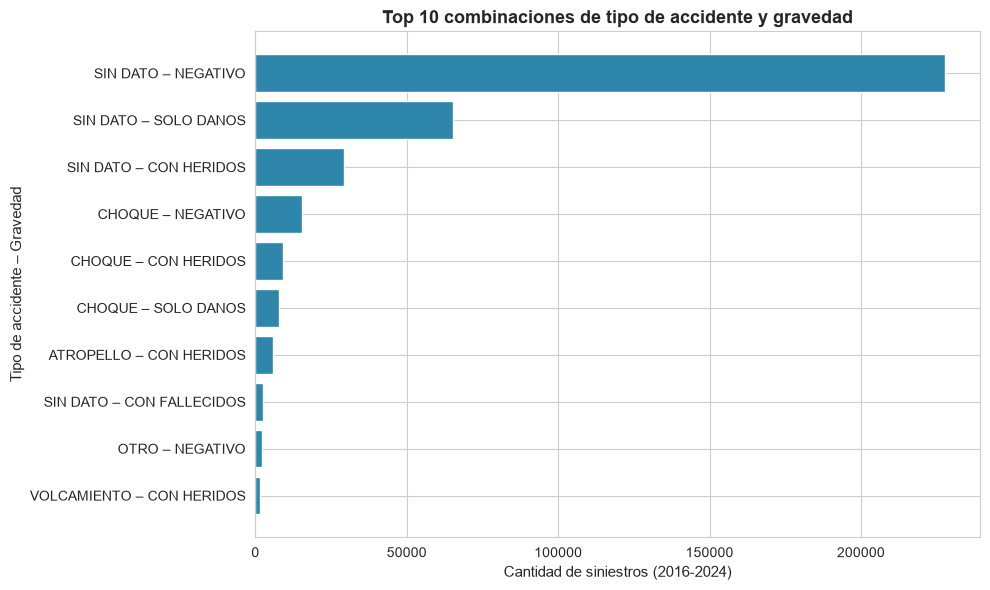

In [18]:
top10_combos = (
    r6.assign(combinacion=r6["tipo_accidente_estandarizado"] + " – " + r6["gravedad_estandarizada"])
    .groupby("combinacion")["cantidad_siniestros"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10_combos.index[::-1], top10_combos.values[::-1], color=COLOR_PRINCIPAL)
ax.set_title("Top 10 combinaciones de tipo de accidente y gravedad")
ax.set_xlabel("Cantidad de siniestros (2016-2024)")
ax.set_ylabel("Tipo de accidente – Gravedad")
plt.tight_layout()

# Guardar la gráfica
plt.savefig(
    "graficas/grafica_8_top_combinaciones.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Insight:** La combinación SIN DATO – NEGATIVO encabeza el ranking por un margen amplio, reflejando el peso de los registros sin clasificación completa del tipo de accidente ni confirmación de gravedad: una limitación de calidad de datos que conviene mencionar en el informe de la Fase E. Entre las combinaciones con información completa, CHOQUE aparece de forma recurrente como una de las más frecuentes, tanto en episodios sin heridos como con heridos. Esto confirma que el choque es el tipo de accidente predominante en la ciudad.